# 05.05 Pandas의 시각화 기능

Pandas의 시리즈나 데이터프레임은 `plot`이라는 시각화 메서드를 내장하고 있다. `plot`은 matplotlib를 내부에서 임포트하여 사용한다. 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

In [20]:
pd.date_range('2/26/2026', periods=100) # 날짜 100개

DatetimeIndex(['2026-02-26', '2026-02-27', '2026-02-28', '2026-03-01',
               '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05',
               '2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09',
               '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13',
               '2026-03-14', '2026-03-15', '2026-03-16', '2026-03-17',
               '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-21',
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02',
               '2026-04-03', '2026-04-04', '2026-04-05', '2026-04-06',
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-11', '2026-04-12', '2026-04-13', '2026-04-14',
               '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-18',
               '2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22',
      

In [2]:
df1 = pd.DataFrame(np.random.randn(100, 3),
                   index=pd.date_range('1/1/2020', periods=100),
                   columns=['A', 'B', 'C']).cumsum()
df1

,A,B,C
2020-01-01,1.764052,0.400157,0.978738
2020-01-02,4.004946,2.267715,0.001460
2020-01-03,4.955034,2.116358,-0.101759
2020-01-04,5.365632,2.260402,1.352515
2020-01-05,6.126670,2.382077,1.796378
...,...,...,...
2020-04-05,9.396256,6.282026,-11.198087
2020-04-06,10.086074,7.583872,-11.826175
2020-04-07,9.605047,9.887789,-12.886190
2020-04-08,9.469097,11.024680,-12.788465


In [21]:
import matplotlib as mpl
mpl.rc('font', family="Malgun Gothic")
mpl.rc('axes', unicode_minus=False)

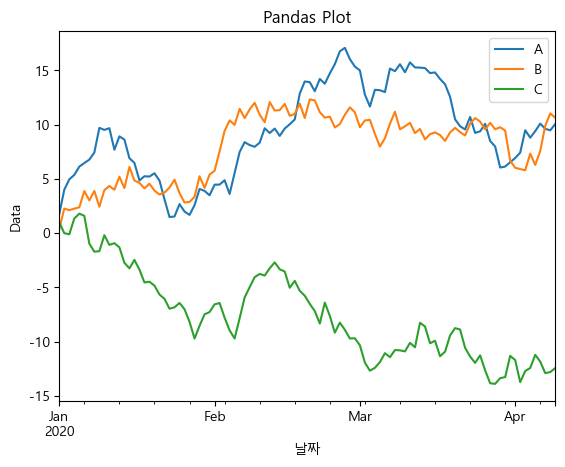

In [22]:
df1.plot()
plt.title("Pandas Plot")
plt.xlabel("날짜")
plt.ylabel("Data")
plt.show()

`plot` 메서드의 `kind`라는 인수를 바꾸면 여러가지 플롯을 그릴 수 있다. 다음과 같은 인수값을 지원한다.

* `bar`
* `pie`
* `hist`
* `kde`
* `box`
* `scatter`
* `area`


In [23]:
import seaborn as sns
iris = sns.load_dataset("iris")    # 붓꽃 데이터
titanic = sns.load_dataset("titanic")    # 타이타닉호 데이터

In [24]:
iris.sepal_length[:20]

0     5.1
1     4.9
2     4.7
3     4.6
4     5.0
5     5.4
6     4.6
7     5.0
8     4.4
9     4.9
10    5.4
11    4.8
12    4.8
13    4.3
14    5.8
15    5.7
16    5.4
17    5.1
18    5.7
19    5.1
Name: sepal_length, dtype: float64

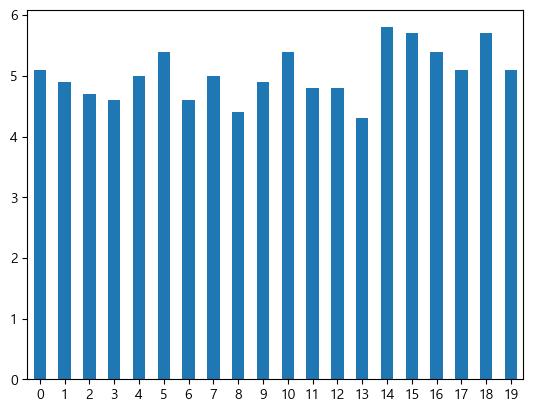

In [29]:
iris.sepal_length[:20].plot(kind='bar', rot=0)
plt.show()

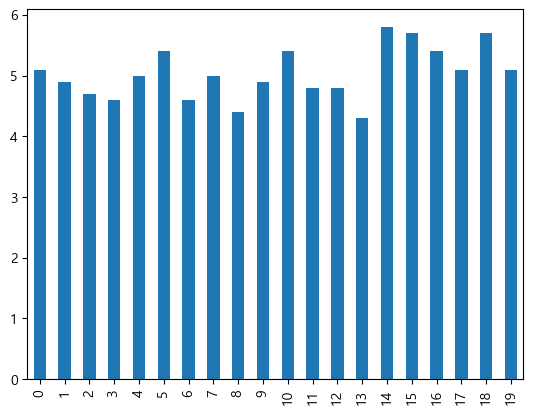

In [34]:
iris.sepal_length[:20].plot(kind='bar', rot=90)
plt.show()

`kind` 인수에 문자열을 쓰는 대신 `plot.bar`처럼 직접 메서드로 사용할 수도 있다.

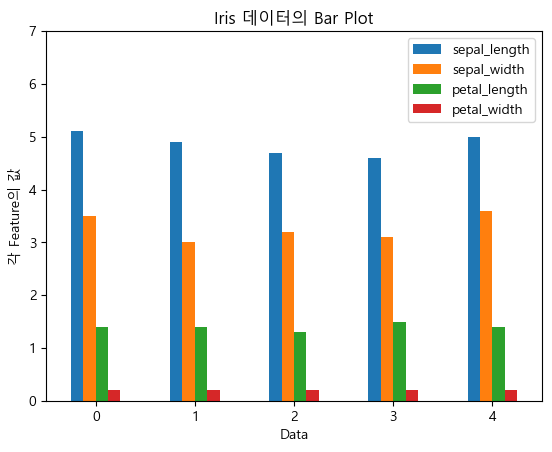

In [26]:
iris[:5].plot.bar(rot=0)
plt.title("Iris 데이터의 Bar Plot")
plt.xlabel("Data")
plt.ylabel("각 Feature의 값")
plt.ylim(0, 7)
plt.show()

다음은 그룹분석으로 각 붓꽃종의 특징값의 평균을 구한 것이다.

In [38]:
df2 = iris.groupby(iris.species).mean()
df2.columns.name = "feature"  # in-place method
df2

feature,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


그룹분석 결과도 데이터프레임이므로 같은 방식으로 시각화할 수 있다.

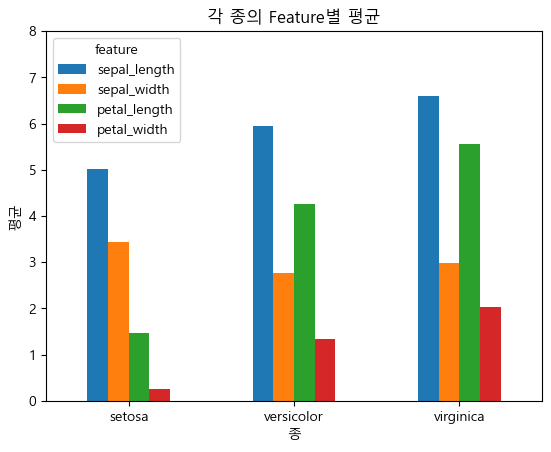

In [10]:
df2.plot.bar(rot=0)
plt.title("각 종의 Feature별 평균")
plt.xlabel("종")
plt.ylabel("평균")
plt.ylim(0, 8)
plt.show()

전치연산으로 시각화 방법을 다르게 할 수도 있다.

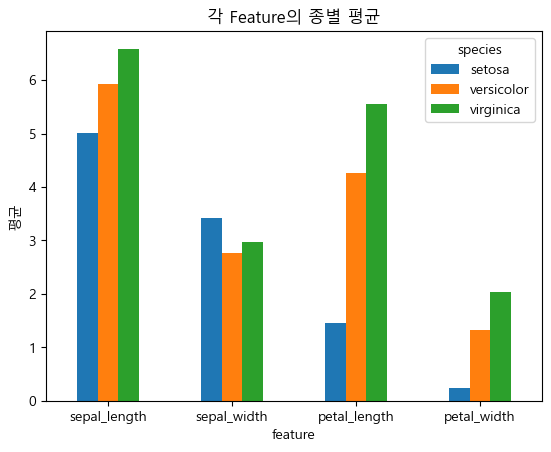

In [39]:
df2.T.plot.bar(rot=0)
plt.title("각 Feature의 종별 평균")
plt.ylabel("평균")
plt.show()

다음은 ``pie``,  ``hist``, ``kde``, ``box``, ``scatter`` 플롯 예제이다.

In [36]:
df3 = titanic["class"].value_counts()
df3

class
Third     491
First     216
Second    184
Name: count, dtype: int64

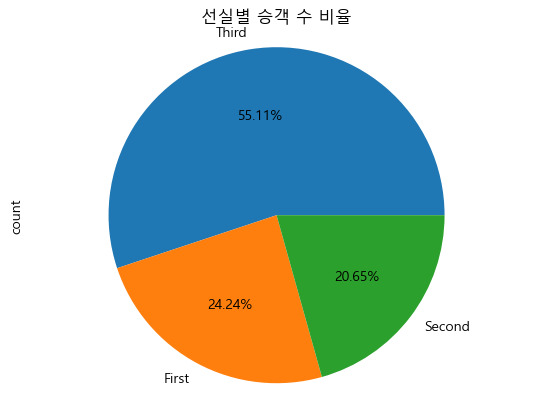

In [37]:
df3.plot.pie(autopct='%.2f%%')
plt.title("선실별 승객 수 비율")
plt.axis('equal')
plt.show()

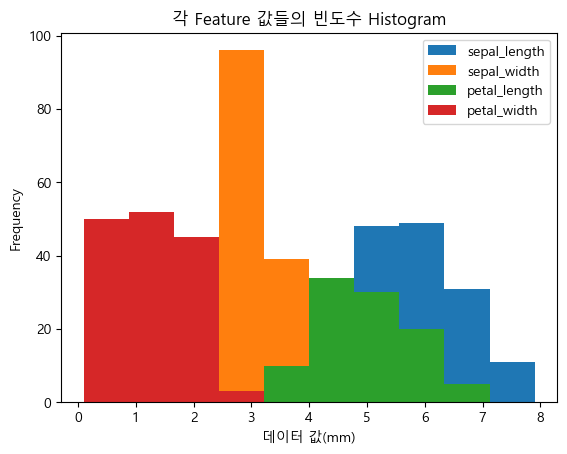

In [14]:
iris.plot.hist()
plt.title("각 Feature 값들의 빈도수 Histogram")
plt.xlabel("데이터 값(mm)")
plt.show()

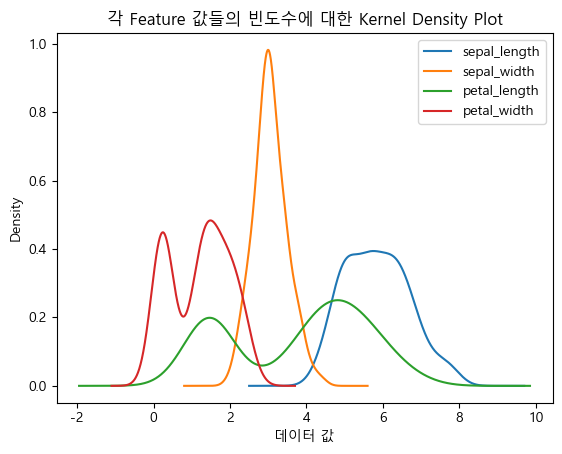

In [40]:
iris.plot.kde()
plt.title("각 Feature 값들의 빈도수에 대한 Kernel Density Plot")
plt.xlabel("데이터 값")
plt.show()

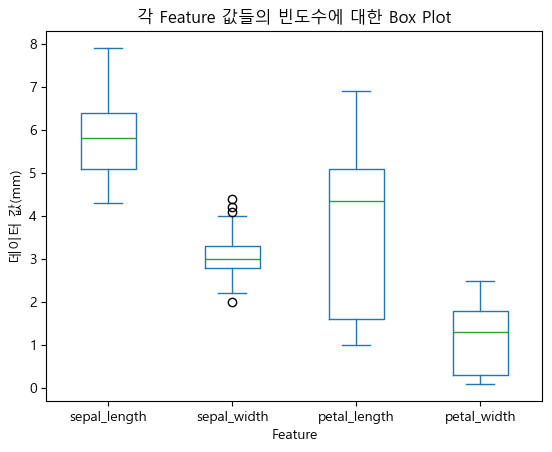

In [16]:
iris.plot.box()
plt.title("각 Feature 값들의 빈도수에 대한 Box Plot")
plt.xlabel("Feature")
plt.ylabel("데이터 값(mm)")
plt.show()

박스플롯에 대해서는 추가적인 기능을 가진 `boxplot` 명령이 별도로 있다.

 ```DataFrame.boxplot(column=None, by=None, ax=None, fontsize=None, rot=0, grid=True, figsize=None, layout=None, return_type=None, backend=None, **kwargs```

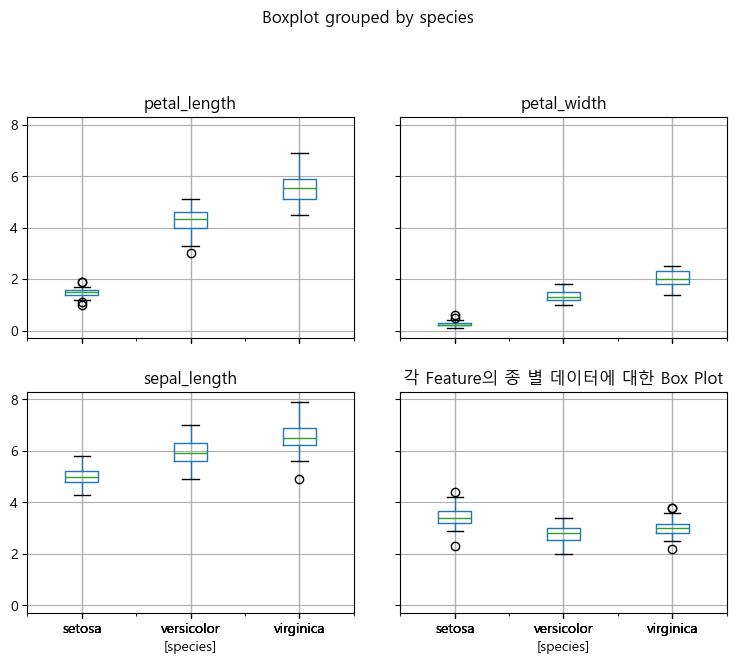

In [17]:
iris.boxplot(by='species', figsize=(8, 7))
plt.tight_layout(pad=3, h_pad=2)
plt.title("각 Feature의 종 별 데이터에 대한 Box Plot")
plt.show()